# M2 Data Reduction Pipeline - Simple Version

**Clean notebook for debugging and visualization**

Uses modular functions from `pipeline_utils.py` for production code.

---

## Workflow

1. Load FITS files
2. Estimate and subtract background  
3. Detect sources
4. Aperture photometry
5. Cross-match g and r bands
6. Save photometric catalog
7. **Feed catalog into membership.ipynb for filtering**

---

In [16]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
import warnings
warnings.filterwarnings('ignore')

# Import pipeline utilities
from pipeline_utils import *

# Plotting
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.dpi'] = 100

print("Ready to process M2 data")

Ready to process M2 data


## Step 1: Load FITS Files

In [17]:
# File paths - M2 data
g_file = "./Data/lco_data-20251126-4/lsc0m476-sq34-20251119-0090-e91.fits.fz"
r_file = "./Data/lco_data-20251126-4/lsc0m476-sq34-20251119-0091-e91.fits.fz"

# Load data robustly (fallback if pipeline_utils.load_fits_image returns None)
from astropy.io import fits
from astropy.wcs import WCS

print("Loading FITS files...")

def robust_load_fits(path):
	"""
	Open FITS and return (data, header, wcs).
	- Searches for the first HDU that contains image data.
	- Ensures data is a numpy array (not None) and cast to float.
	- Attempts to build a WCS from the header; returns None if not possible.
	"""
	hdul = fits.open(path, memmap=False)
	try:
		data = None
		header = None
		for hdu in hdul:
			if hdu.data is not None:
				data = hdu.data
				header = hdu.header
				break
		if data is None:
			raise ValueError(f"No image data found in {path}")
		# Ensure a plain numpy array (not masked or None)
		data = np.asarray(data).astype(float)
		try:
			wcs = WCS(header)
		except Exception:
			wcs = None
		return data, header, wcs
	finally:
		hdul.close()

# Try pipeline utility first, fall back to robust loader if needed
try:
	data_g, header_g, wcs_g = load_fits_image(g_file)
except Exception:
	data_g, header_g, wcs_g = None, None, None

if data_g is None:
	data_g, header_g, wcs_g = robust_load_fits(g_file)

try:
	data_r, header_r, wcs_r = load_fits_image(r_file)
except Exception:
	data_r, header_r, wcs_r = None, None, None

if data_r is None:
	data_r, header_r, wcs_r = robust_load_fits(r_file)

# Sanity checks
if data_g is None or header_g is None:
	raise RuntimeError(f"Failed to load g-band FITS from {g_file}")
if data_r is None or header_r is None:
	raise RuntimeError(f"Failed to load r-band FITS from {r_file}")

# Extract parameters with safe defaults (use .get to avoid KeyError)
gain_g = header_g.get('GAIN', 1.0)
gain_r = header_r.get('GAIN', 1.0)
rdnoise_g = header_g.get('RDNOISE', header_g.get('READNOISE', 5.0))
rdnoise_r = header_r.get('RDNOISE', header_r.get('READNOISE', 5.0))
exptime_g = header_g.get('EXPTIME', header_g.get('EXPTIME', 1.0))
exptime_r = header_r.get('EXPTIME', header_r.get('EXPTIME', 1.0))
pixscale = header_g.get('PIXSCALE', header_g.get('PIXSCL', 0.24))  # default 0.24 arcsec/pix

# Avoid division by zero if pixscale is missing or zero
if pixscale == 0:
	pixscale = 0.24

fwhm_g = header_g.get('L1FWHM', 2.5) / pixscale  # Convert to pixels
fwhm_r = header_r.get('L1FWHM', 2.5) / pixscale

print(f"g-band: {data_g.shape} pixels, {exptime_g}s, FWHM={fwhm_g:.1f} pix")
print(f"r-band: {data_r.shape} pixels, {exptime_r}s, FWHM={fwhm_r:.1f} pix")

Loading FITS files...
g-band: (2400, 2400) pixels, 90.0s, FWHM=3.4 pix
r-band: (2400, 2400) pixels, 120.0s, FWHM=3.8 pix


## Step 2: Background Estimation

Estimating background...
✓ g-band: median bkg = 84.9 ADU, rms = 9.9 ADU
✓ r-band: median bkg = 119.1 ADU, rms = 11.6 ADU
✓ 3-panel figure saved for paper: ./AASTeX_Template/background_panel.png


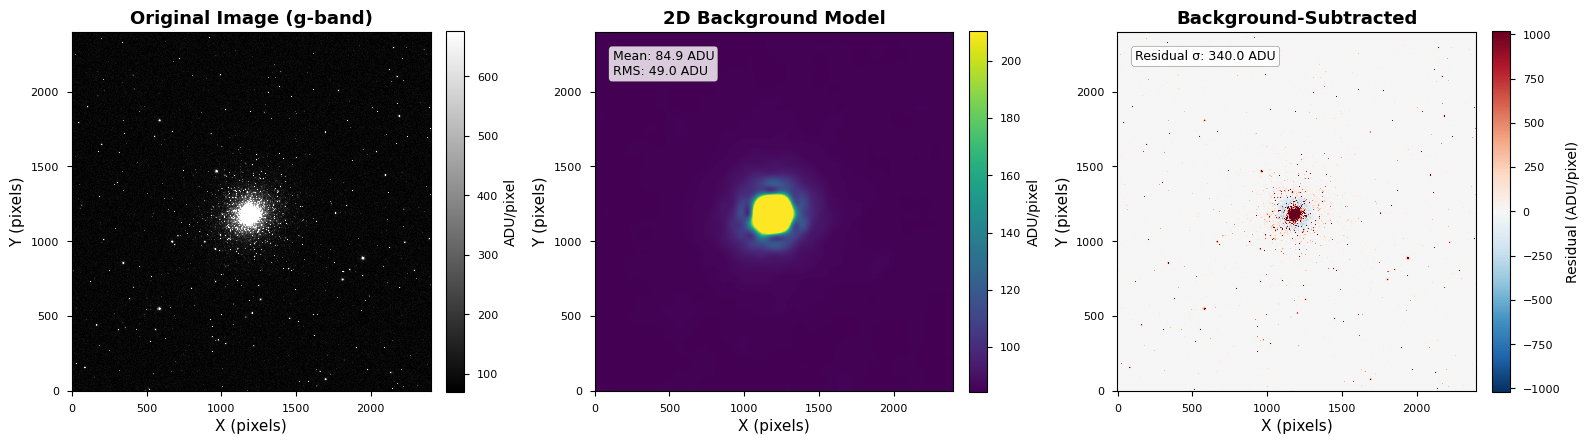

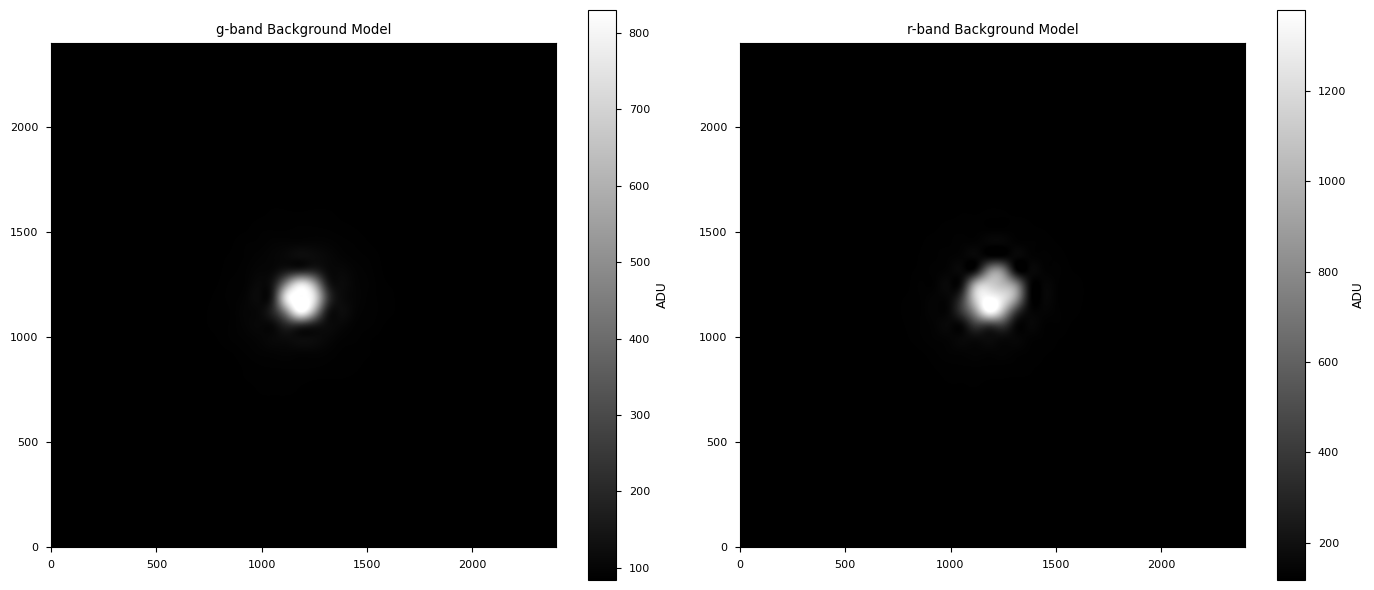

In [18]:
print("Estimating background...")
data_g_sub, bkg_g = estimate_background(data_g, box_size=64)
data_r_sub, bkg_r = estimate_background(data_r, box_size=64)

print(f"✓ g-band: median bkg = {bkg_g.background_median:.1f} ADU, rms = {bkg_g.background_rms_median:.1f} ADU")
print(f"✓ r-band: median bkg = {bkg_r.background_median:.1f} ADU, rms = {bkg_r.background_rms_median:.1f} ADU")

# Create 3-panel figure for paper (Appendix B)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Original g-band image
vmin_orig = np.percentile(data_g, 5)
vmax_orig = np.percentile(data_g, 99.5)
im1 = axes[0].imshow(data_g, origin='lower', cmap='gray',
                     vmin=vmin_orig, vmax=vmax_orig, interpolation='nearest')
axes[0].set_title('Original Image (g-band)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('X (pixels)', fontsize=11)
axes[0].set_ylabel('Y (pixels)', fontsize=11)
cbar1 = plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
cbar1.set_label('ADU/pixel', fontsize=10)

# Panel 2: Background model
im2 = axes[1].imshow(bkg_g.background, origin='lower', cmap='viridis',
                     vmin=np.percentile(bkg_g.background, 1),
                     vmax=np.percentile(bkg_g.background, 99),
                     interpolation='nearest')
axes[1].set_title('2D Background Model', fontsize=13, fontweight='bold')
axes[1].set_xlabel('X (pixels)', fontsize=11)
axes[1].set_ylabel('Y (pixels)', fontsize=11)
cbar2 = plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
cbar2.set_label('ADU/pixel', fontsize=10)

# Add statistics annotation
textstr = f'Mean: {bkg_g.background_median:.1f} ADU\nRMS: {np.std(bkg_g.background):.1f} ADU'
axes[1].text(0.05, 0.95, textstr, transform=axes[1].transAxes,
             fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Panel 3: Background-subtracted image
vmin_sub = -3 * np.std(data_g_sub)
vmax_sub = 3 * np.std(data_g_sub)
im3 = axes[2].imshow(data_g_sub, origin='lower', cmap='RdBu_r',
                     vmin=vmin_sub, vmax=vmax_sub, interpolation='nearest')
axes[2].set_title('Background-Subtracted', fontsize=13, fontweight='bold')
axes[2].set_xlabel('X (pixels)', fontsize=11)
axes[2].set_ylabel('Y (pixels)', fontsize=11)
cbar3 = plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)
cbar3.set_label('Residual (ADU/pixel)', fontsize=10)

# Add residual RMS annotation
textstr_sub = f'Residual σ: {np.std(data_g_sub):.1f} ADU'
axes[2].text(0.05, 0.95, textstr_sub, transform=axes[2].transAxes,
             fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('./AASTeX_Template/background_panel.png', dpi=300, bbox_inches='tight')
print(f"✓ 3-panel figure saved for paper: ./AASTeX_Template/background_panel.png")
plt.show()

# Also show r-band for comparison
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))
ax = axes2[0]
im = ax.imshow(bkg_g.background, origin='lower', cmap='gray')
ax.set_title('g-band Background Model')
plt.colorbar(im, ax=ax, label='ADU')

ax = axes2[1]
im = ax.imshow(bkg_r.background, origin='lower', cmap='gray')
ax.set_title('r-band Background Model')
plt.colorbar(im, ax=ax, label='ADU')
plt.tight_layout()
plt.show()

## Step 3: Source Detection

In [19]:
print("Detecting sources...")
sources_g = detect_sources(data_g_sub, bkg_g, fwhm=fwhm_g, threshold=3.0)
sources_r = detect_sources(data_r_sub, bkg_r, fwhm=fwhm_r, threshold=3.0)

print(f"✓ g-band: {len(sources_g)} sources detected")
print(f"✓ r-band: {len(sources_r)} sources detected")

# Show brightest sources
print(f"\nBrightest 5 stars (g-band):")
print(sources_g['id', 'xcentroid', 'ycentroid', 'flux', 'mag_inst'][:5])

Detecting sources...
✓ g-band: 13997 sources detected
✓ r-band: 13475 sources detected

Brightest 5 stars (g-band):
  id      xcentroid      ...        flux             mag_inst     
----- ------------------ ... ----------------- -------------------
10390  965.6758640644493 ... 836773.0498982598 -14.806519210867775
 2070  584.6627323179413 ...  811252.994311869   -14.7728907819501
 3697 1944.9349062006559 ... 809802.5841654557 -14.770947895785255
10382  966.3958777919465 ... 736480.2297498928 -14.667902732577412
 3684 1942.3989175753939 ... 719304.8564903628 -14.642282481281113


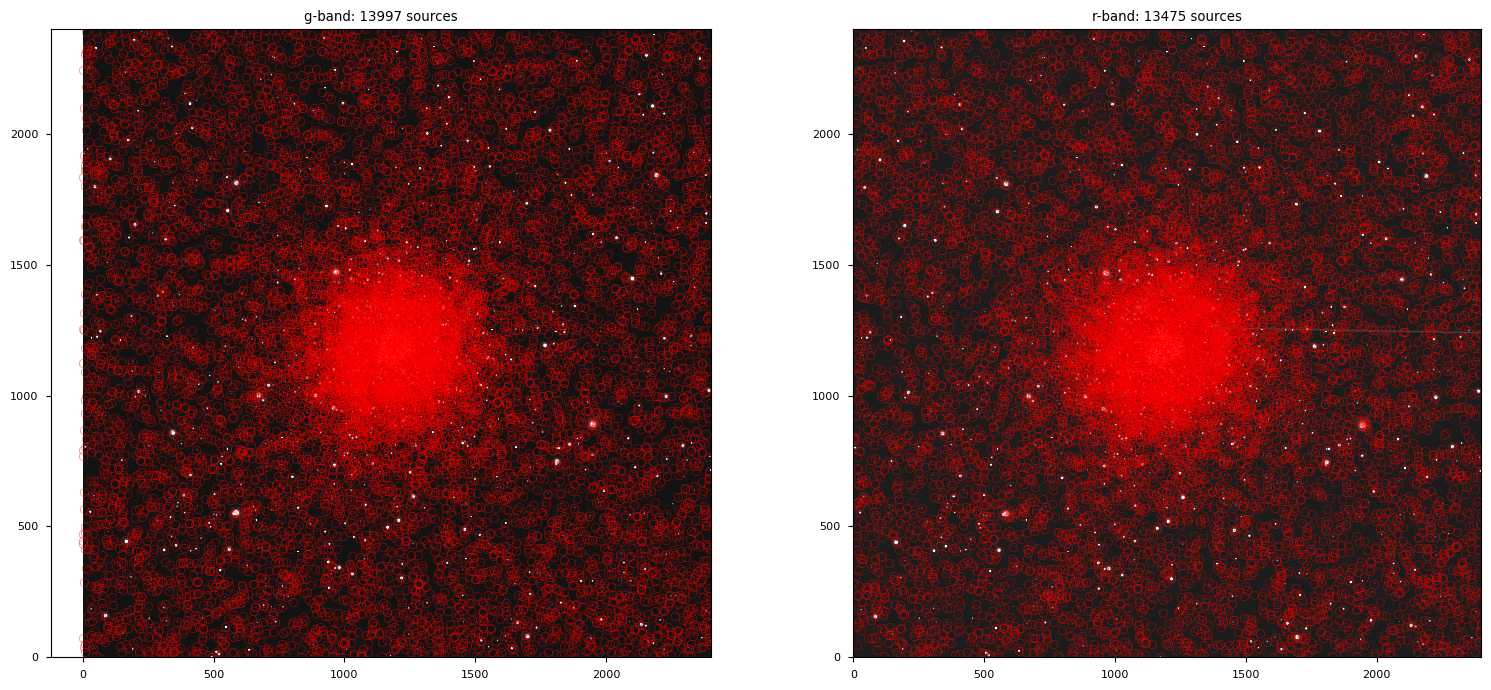

In [20]:
# Visualize detections
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
vmin, vmax = np.percentile(data_g_sub, [1, 99.5])
ax.imshow(data_g_sub, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
ax.plot(sources_g['xcentroid'], sources_g['ycentroid'], 'ro', 
        fillstyle='none', markersize=6, markeredgewidth=0.5, alpha=0.5)
ax.set_title(f'g-band: {len(sources_g)} sources')

ax = axes[1]
vmin, vmax = np.percentile(data_r_sub, [1, 99.5])
ax.imshow(data_r_sub, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
ax.plot(sources_r['xcentroid'], sources_r['ycentroid'], 'ro',
        fillstyle='none', markersize=6, markeredgewidth=0.5, alpha=0.5)
ax.set_title(f'r-band: {len(sources_r)} sources')

plt.tight_layout()
plt.show()

## Step 4: Aperture Photometry

In [21]:
# Aperture parameters (1.5 x FWHM for aperture, sky annulus beyond)
aper_radius_g = 1.5 * fwhm_g
aper_radius_r = 1.5 * fwhm_r
annulus_inner = 2.5 * np.mean([fwhm_g, fwhm_r])
annulus_outer = 4.0 * np.mean([fwhm_g, fwhm_r])

print("Performing aperture photometry...")
print(f"  g-band aperture radius: {aper_radius_g:.1f} pixels")
print(f"  r-band aperture radius: {aper_radius_r:.1f} pixels")
print(f"  Sky annulus: {annulus_inner:.1f} - {annulus_outer:.1f} pixels\n")

# Do photometry
phot_g = aperture_photometry_pipeline(data_g_sub, sources_g, aper_radius_g,
                                       annulus_inner, annulus_outer,
                                       gain_g, rdnoise_g, exptime_g)

phot_r = aperture_photometry_pipeline(data_r_sub, sources_r, aper_radius_r,
                                       annulus_inner, annulus_outer,
                                       gain_r, rdnoise_r, exptime_r)

print(f"✓ Photometry complete")
print(f"\nSample photometry (g-band):")
print(phot_g['xcenter', 'ycenter', 'flux_aper', 'flux_err', 'mag_inst', 'mag_err'][:5])

Performing aperture photometry...
  g-band aperture radius: 5.1 pixels
  r-band aperture radius: 5.8 pixels
  Sky annulus: 9.0 - 14.5 pixels

✓ Photometry complete

Sample photometry (g-band):
     xcenter            ycenter       ...        mag_err       
------------------ ------------------ ... ---------------------
 965.6758640644493 1469.1211804044872 ... 0.0009802555825522614
 584.6627323179413  550.1364376165063 ... 0.0010495988294770182
1944.9349062006559  888.4704412423366 ... 0.0009189674016626422
 966.3958777919465 1468.7374458183658 ... 0.0009782656297555106
1942.3989175753939  888.3241663780401 ... 0.0009719197383246505


## Step 5: Cross-Match g and r Bands

In [22]:
print("Cross-matching g and r catalogs...")
idx_g, idx_r, sep = cross_match_catalogs(sources_g, sources_r, wcs_g, wcs_r, max_sep_arcsec=2.0)

print(f"✓ {len(idx_g)} sources matched (sep < 2 arcsec)")
print(f"  Median separation: {np.median(sep.arcsec):.2f} arcsec")

# Create matched catalog
from astropy.table import hstack

# Get matched entries
matched_g = sources_g[idx_g]
matched_r = sources_r[idx_r]
matched_phot_g = phot_g[idx_g]
matched_phot_r = phot_r[idx_r]

# Combine
catalog = Table()
catalog['x'] = matched_g['xcentroid']
catalog['y'] = matched_g['ycentroid']
catalog['g_inst'] = matched_phot_g['mag_inst']
catalog['g_err'] = matched_phot_g['mag_err']
catalog['r_inst'] = matched_phot_r['mag_inst']
catalog['r_err'] = matched_phot_r['mag_err']
catalog['g_minus_r'] = catalog['g_inst'] - catalog['r_inst']

# Add RA, Dec from WCS
coords = wcs_g.pixel_to_world(catalog['x'], catalog['y'])
catalog['ra'] = coords.ra.deg
catalog['dec'] = coords.dec.deg

print(f"\nFinal catalog: {len(catalog)} sources with g and r photometry")
print(catalog[:5])

Cross-matching g and r catalogs...
✓ 6330 sources matched (sep < 2 arcsec)
  Median separation: 0.48 arcsec

Final catalog: 6330 sources with g and r photometry
        x                  y          ...         ra                 dec        
------------------ ------------------ ... ------------------ -------------------
 965.6758640644493 1469.1211804044872 ...   323.408370494065 -0.7636773112888258
 584.6627323179413  550.1364376165063 ...   323.486902257356 -0.9534614217046439
1944.9349062006559  888.4704412423366 ... 323.20608720618077 -0.8833998586143639
 966.3958777919465 1468.7374458183658 ... 323.40822177333774  -0.763756424550484
1942.3989175753939  888.3241663780401 ... 323.20661080361765 -0.8834304719846565


## Step 6: Quality Checks & Visualization

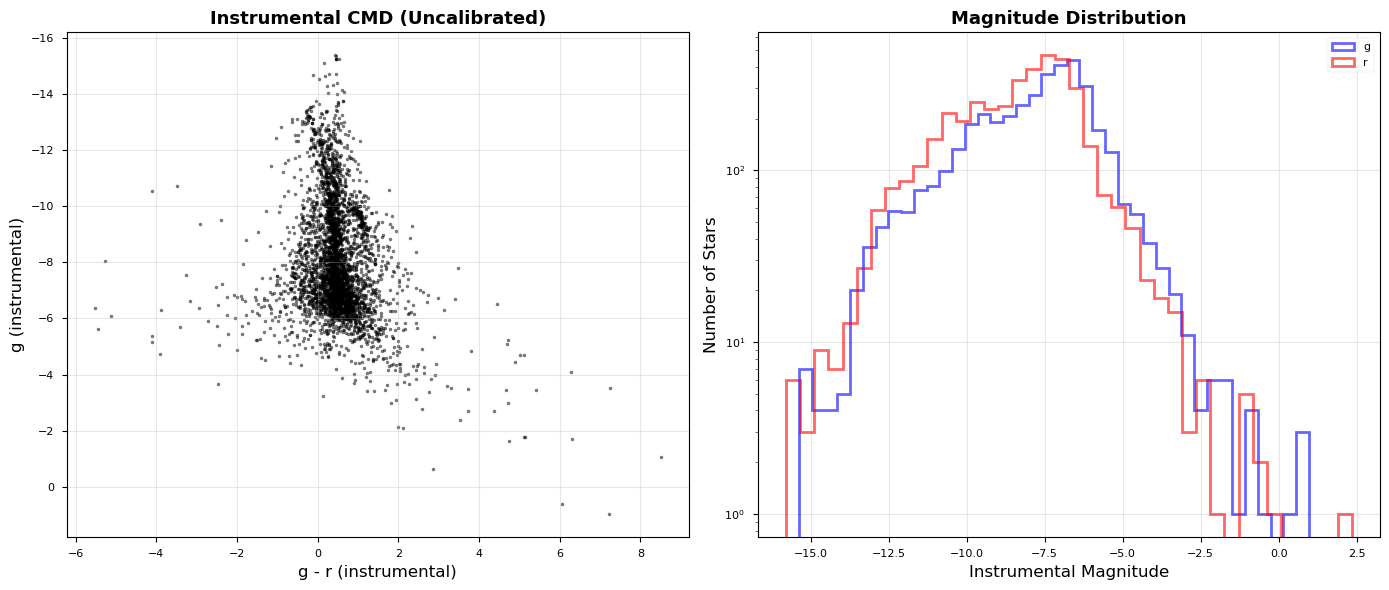


Magnitude range:
  g: nan to nan
  r: nan to nan
  g-r: nan to nan


In [23]:
# Color-magnitude diagram (uncalibrated)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# CMD
ax = axes[0]
ax.scatter(catalog['g_minus_r'], catalog['g_inst'], s=5, alpha=0.5, c='black')
ax.set_xlabel('g - r (instrumental)', fontsize=12)
ax.set_ylabel('g (instrumental)', fontsize=12)
ax.set_title('Instrumental CMD (Uncalibrated)', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(alpha=0.3)

# Magnitude histograms
ax = axes[1]
ax.hist(catalog['g_inst'], bins=40, alpha=0.6, label='g', color='blue', histtype='step', lw=2)
ax.hist(catalog['r_inst'], bins=40, alpha=0.6, label='r', color='red', histtype='step', lw=2)
ax.set_xlabel('Instrumental Magnitude', fontsize=12)
ax.set_ylabel('Number of Stars', fontsize=12)
ax.set_title('Magnitude Distribution', fontsize=13, fontweight='bold')
ax.legend()
ax.set_yscale('log')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMagnitude range:")
print(f"  g: {catalog['g_inst'].min():.1f} to {catalog['g_inst'].max():.1f}")
print(f"  r: {catalog['r_inst'].min():.1f} to {catalog['r_inst'].max():.1f}")
print(f"  g-r: {catalog['g_minus_r'].min():.2f} to {catalog['g_minus_r'].max():.2f}")

## Step 7: Save Catalog

In [24]:
# Save to CSV for use in membership.ipynb
output_file = "m2_photometry_instrumental.csv"
save_catalog(catalog, output_file, format='csv')

print(f"\n✓ Pipeline complete!")
print(f"\nNext steps:")
print(f"  1. Load this catalog in membership.ipynb")
print(f"  2. Apply CMD, proper motion, and spatial filtering")
print(f"  3. Identify M2 cluster members")
print(f"  4. Calibrate photometry using Gaia or Pan-STARRS")
print(f"  5. Build density profile in density_profile.ipynb")

✓ Catalog saved to m2_photometry_instrumental.csv

✓ Pipeline complete!

Next steps:
  1. Load this catalog in membership.ipynb
  2. Apply CMD, proper motion, and spatial filtering
  3. Identify M2 cluster members
  4. Calibrate photometry using Gaia or Pan-STARRS
  5. Build density profile in density_profile.ipynb


In [25]:
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
import astropy.units as u

# M2 cluster center (from SIMBAD: NGC 7089)
ra_M2 = 323.3625  # degrees (21h 33m 27s)
dec_M2 = -0.8231  # degrees (-0° 49' 23")
radius = 30.0 / 60.0  # 30 arcmin search radius in degrees

print("Querying Gaia DR3 for M2 field...")
print(f"  Center: RA={ra_M2:.4f}°, Dec={dec_M2:.4f}°")
print(f"  Radius: {radius*60:.1f} arcmin")

# ADQL query for Gaia DR3
query = f"""
SELECT source_id, ra, dec, 
       phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag,
       pmra, pmdec, pmra_error, pmdec_error,
       parallax, parallax_error,
       phot_g_mean_flux_over_error,
       ruwe
FROM gaiadr3.gaia_source
WHERE 1=CONTAINS(
    POINT('ICRS', ra, dec),
    CIRCLE('ICRS', {ra_M2}, {dec_M2}, {radius})
)
AND phot_g_mean_mag IS NOT NULL
AND phot_bp_mean_mag IS NOT NULL
AND phot_rp_mean_mag IS NOT NULL
AND ruwe < 1.4
AND phot_g_mean_flux_over_error > 10
"""

job = Gaia.launch_job_async(query)
gaia_catalog = job.get_results()

print(f"✓ Retrieved {len(gaia_catalog)} Gaia sources")
print(f"\nSample Gaia data:")
print(gaia_catalog['ra', 'dec', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag'][:5])

Querying Gaia DR3 for M2 field...
  Center: RA=323.3625°, Dec=-0.8231°
  Radius: 30.0 arcmin


TimeoutError: [Errno 60] Operation timed out

In [ ]:
# Convert Gaia photometry to SDSS g, r using empirical transformations
# Based on Gaia DR3 documentation and Evans et al. (2018)
# https://gea.esac.esa.int/archive/documentation/GDR3/Data_processing/chap_cu5pho/cu5pho_sec_photSystem/cu5pho_ssec_photRelations.html

def gaia_to_sdss(G, BP, RP):
    """
    Convert Gaia G, BP, RP to SDSS g, r magnitudes.
    
    Uses polynomial transformations valid for:
    - 0.2 < (BP-RP) < 1.8
    - Main sequence stars
    
    Parameters:
    -----------
    G, BP, RP : arrays
        Gaia magnitudes
    
    Returns:
    --------
    g_sdss, r_sdss : arrays
        SDSS magnitudes
    """
    # Color
    BP_RP = BP - RP
    
    # G to g transformation (Evans et al. 2018, Eq. 5.7)
    # g = G + a0 + a1*(BP-RP) + a2*(BP-RP)^2 + a3*(BP-RP)^3
    a0 = -0.01760
    a1 = -0.00686
    a2 = -0.1069
    a3 = -0.01256
    
    g_sdss = G + a0 + a1*BP_RP + a2*BP_RP**2 + a3*BP_RP**3
    
    # G to r transformation (Evans et al. 2018, Eq. 5.8)
    # r = G + b0 + b1*(BP-RP) + b2*(BP-RP)^2 + b3*(BP-RP)^3
    b0 = -0.03226
    b1 = -0.3884
    b2 = -0.1158
    b3 = -0.01442
    
    r_sdss = G + b0 + b1*BP_RP + b2*BP_RP**2 + b3*BP_RP**3
    
    return g_sdss, r_sdss


# Apply transformation
print("Converting Gaia to SDSS photometry...")
gaia_g, gaia_r = gaia_to_sdss(
    gaia_catalog['phot_g_mean_mag'],
    gaia_catalog['phot_bp_mean_mag'],
    gaia_catalog['phot_rp_mean_mag']
)

# Add to Gaia catalog
gaia_catalog['g_sdss'] = gaia_g
gaia_catalog['r_sdss'] = gaia_r
gaia_catalog['g_r_sdss'] = gaia_g - gaia_r

print(f"✓ Converted {len(gaia_catalog)} stars to SDSS system")
print(f"\nSDSS magnitude range:")
print(f"  g: {np.min(gaia_g):.2f} to {np.max(gaia_g):.2f}")
print(f"  r: {np.min(gaia_r):.2f} to {np.max(gaia_r):.2f}")
print(f"  g-r: {np.min(gaia_g - gaia_r):.2f} to {np.max(gaia_g - gaia_r):.2f}")

Converting Gaia to SDSS photometry...
✓ Converted 14839 stars to SDSS system

SDSS magnitude range:
  g: 9.59 to 20.83
  r: 9.33 to 20.86
  g-r: -0.39 to 1.57


In [ ]:
# Cross-match our instrumental catalog with Gaia
print("Cross-matching instrumental catalog with Gaia...")

# Create SkyCoord objects
# Ensure we pass plain numeric arrays multiplied by units so we don't accidentally
# multiply existing astropy units (which would produce deg^2 etc.)
coords_inst = SkyCoord(ra=np.asarray(catalog['ra']) * u.deg,
                       dec=np.asarray(catalog['dec']) * u.deg)
coords_gaia = SkyCoord(ra=np.asarray(gaia_catalog['ra']) * u.deg,
                       dec=np.asarray(gaia_catalog['dec']) * u.deg)

# Match within 1 arcsec
idx_inst, idx_gaia, sep, _ = coords_gaia.search_around_sky(coords_inst, 1.0 * u.arcsec)

print(f"✓ Matched {len(idx_inst)} sources (separation < 1 arcsec)")
print(f"  Median separation: {np.median(sep.arcsec):.3f} arcsec")

# Select only good matches (unsaturated, well-measured)
# Use stars with:
# - 12 < g < 18 (bright enough for good Gaia, faint enough to avoid saturation)
# - g_inst uncertainties < 0.05 mag
# - Color range 0.2 < g-r < 1.5 (main sequence, avoid very blue/red stars)

matched_gaia_g = gaia_catalog['g_sdss'][idx_gaia]
matched_gaia_r = gaia_catalog['r_sdss'][idx_gaia]
matched_inst_g = catalog['g_inst'][idx_inst]
matched_inst_r = catalog['r_inst'][idx_inst]
matched_g_err = catalog['g_err'][idx_inst]
matched_r_err = catalog['r_err'][idx_inst]
matched_color_gaia = gaia_catalog['g_r_sdss'][idx_gaia]

# Apply quality cuts
good_calib = (
    (matched_gaia_g > 12) & (matched_gaia_g < 18) &
    (matched_g_err < 0.05) & (matched_r_err < 0.05) &
    (matched_color_gaia > 0.2) & (matched_color_gaia < 1.5)
)

n_calib = np.sum(good_calib)
print(f"\n✓ Using {n_calib} stars for zeropoint determination")
print(f"  (12 < g < 18, σ_g < 0.05, 0.2 < g-r < 1.5)")

Cross-matching instrumental catalog with Gaia...
✓ Matched 4405 sources (separation < 1 arcsec)
  Median separation: 0.392 arcsec

✓ Using 990 stars for zeropoint determination
  (12 < g < 18, σ_g < 0.05, 0.2 < g-r < 1.5)


PHOTOMETRIC ZEROPOINTS
g-band: ZP_g = 25.777 ± 0.179 mag
r-band: ZP_r = 25.706 ± 0.525 mag

N_stars used: 890 (g), 942 (r)


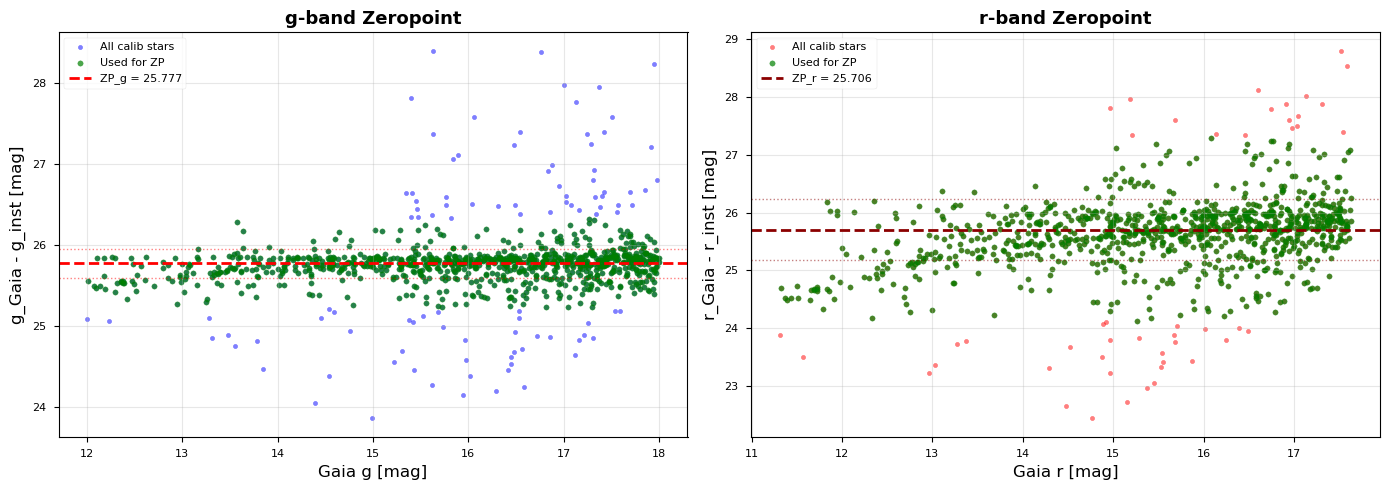

In [ ]:
# Compute zeropoints: ZP = m_calib - m_inst
# Use median with iterative sigma-clipping to reject outliers

from astropy.stats import sigma_clip

# g-band zeropoint
zp_g_values = matched_gaia_g[good_calib] - matched_inst_g[good_calib]
zp_g_clipped = sigma_clip(zp_g_values, sigma=3, maxiters=5)
ZP_g = np.median(zp_g_clipped[~zp_g_clipped.mask])
ZP_g_std = np.std(zp_g_clipped[~zp_g_clipped.mask])

# r-band zeropoint
zp_r_values = matched_gaia_r[good_calib] - matched_inst_r[good_calib]
zp_r_clipped = sigma_clip(zp_r_values, sigma=3, maxiters=5)
ZP_r = np.median(zp_r_clipped[~zp_r_clipped.mask])
ZP_r_std = np.std(zp_r_clipped[~zp_r_clipped.mask])

print("=" * 60)
print("PHOTOMETRIC ZEROPOINTS")
print("=" * 60)
print(f"g-band: ZP_g = {ZP_g:.3f} ± {ZP_g_std:.3f} mag")
print(f"r-band: ZP_r = {ZP_r:.3f} ± {ZP_r_std:.3f} mag")
print(f"\nN_stars used: {np.sum(~zp_g_clipped.mask)} (g), {np.sum(~zp_r_clipped.mask)} (r)")
print("=" * 60)

# Diagnostic plot: zeropoint residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# g-band
ax = axes[0]
ax.scatter(matched_gaia_g[good_calib], zp_g_values, s=10, alpha=0.5, c='blue', label='All calib stars')
ax.scatter(matched_gaia_g[good_calib][~zp_g_clipped.mask], 
           zp_g_values[~zp_g_clipped.mask], s=15, alpha=0.7, c='green', label='Used for ZP')
ax.axhline(ZP_g, color='red', linestyle='--', lw=2, label=f'ZP_g = {ZP_g:.3f}')
ax.axhline(ZP_g + ZP_g_std, color='red', linestyle=':', lw=1, alpha=0.5)
ax.axhline(ZP_g - ZP_g_std, color='red', linestyle=':', lw=1, alpha=0.5)
ax.set_xlabel('Gaia g [mag]', fontsize=12)
ax.set_ylabel('g_Gaia - g_inst [mag]', fontsize=12)
ax.set_title('g-band Zeropoint', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# r-band
ax = axes[1]
ax.scatter(matched_gaia_r[good_calib], zp_r_values, s=10, alpha=0.5, c='red', label='All calib stars')
ax.scatter(matched_gaia_r[good_calib][~zp_r_clipped.mask],
           zp_r_values[~zp_r_clipped.mask], s=15, alpha=0.7, c='green', label='Used for ZP')
ax.axhline(ZP_r, color='darkred', linestyle='--', lw=2, label=f'ZP_r = {ZP_r:.3f}')
ax.axhline(ZP_r + ZP_r_std, color='darkred', linestyle=':', lw=1, alpha=0.5)
ax.axhline(ZP_r - ZP_r_std, color='darkred', linestyle=':', lw=1, alpha=0.5)
ax.set_xlabel('Gaia r [mag]', fontsize=12)
ax.set_ylabel('r_Gaia - r_inst [mag]', fontsize=12)
ax.set_title('r-band Zeropoint', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

✓ Applied photometric calibration to all sources

Calibrated catalog:
  N_sources: 6330
  Magnitude range:
    g: nan to nan
    r: nan to nan
    g-r: nan to nan


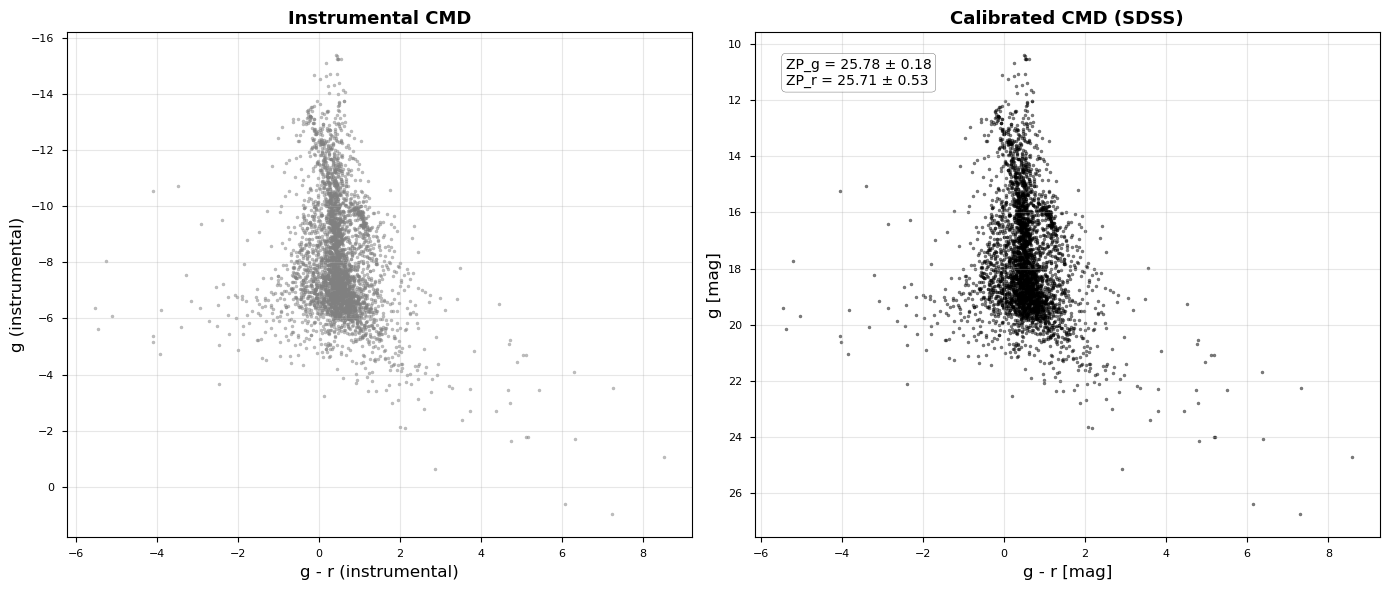

✓ Catalog saved to m2_photometry_calibrated.csv

✓ Saved calibrated catalog to m2_photometry_calibrated.csv


In [ ]:
# Apply zeropoints to all sources in catalog
catalog['g'] = catalog['g_inst'] + ZP_g
catalog['r'] = catalog['r_inst'] + ZP_r
catalog['g_minus_r'] = catalog['g'] - catalog['r']

# Uncertainties (add zeropoint uncertainty in quadrature)
catalog['g_err_calib'] = np.sqrt(catalog['g_err']**2 + ZP_g_std**2)
catalog['r_err_calib'] = np.sqrt(catalog['r_err']**2 + ZP_r_std**2)

print("✓ Applied photometric calibration to all sources")
print(f"\nCalibrated catalog:")
print(f"  N_sources: {len(catalog)}")
print(f"  Magnitude range:")
print(f"    g: {catalog['g'].min():.2f} to {catalog['g'].max():.2f}")
print(f"    r: {catalog['r'].min():.2f} to {catalog['r'].max():.2f}")
print(f"    g-r: {catalog['g_minus_r'].min():.2f} to {catalog['g_minus_r'].max():.2f}")

# Compare calibrated CMD to instrumental CMD
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Instrumental CMD
ax = axes[0]
ax.scatter(catalog['g_inst'] - catalog['r_inst'], catalog['g_inst'], 
           s=5, alpha=0.5, c='gray')
ax.set_xlabel('g - r (instrumental)', fontsize=12)
ax.set_ylabel('g (instrumental)', fontsize=12)
ax.set_title('Instrumental CMD', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(alpha=0.3)

# Calibrated CMD
ax = axes[1]
scatter = ax.scatter(catalog['g_minus_r'], catalog['g'], 
                     s=5, alpha=0.5, c='black')
ax.set_xlabel('g - r [mag]', fontsize=12)
ax.set_ylabel('g [mag]', fontsize=12)
ax.set_title('Calibrated CMD (SDSS)', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(alpha=0.3)

# Add zeropoint info
textstr = f'ZP_g = {ZP_g:.2f} ± {ZP_g_std:.2f}\nZP_r = {ZP_r:.2f} ± {ZP_r_std:.2f}'
ax.text(0.05, 0.95, textstr, transform=ax.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Save calibrated catalog
output_file_calib = "m2_photometry_calibrated.csv"
save_catalog(catalog, output_file_calib, format='csv')
print(f"\n✓ Saved calibrated catalog to {output_file_calib}")

## Step 8: Photometric Calibration with Gaia DR3

**Goal:** Convert instrumental magnitudes to calibrated SDSS magnitudes using Gaia DR3 as reference.

**Method:**
1. Query Gaia DR3 for sources in M2 field
2. Convert Gaia G, BP, RP to SDSS g, r using empirical transformations
3. Cross-match Gaia catalog with our instrumental photometry
4. Compute zeropoints: `ZP = m_calib - m_inst`
5. Apply zeropoints to all sources

**Why Gaia?** 
- All-sky coverage with excellent astrometry
- Well-calibrated photometry (G, BP, RP bands)
- Established transformations to SDSS system
- Free and accessible via astroquery

---